# OKCupid Date-A-Scientist

## Project Scoping
1. **Goal:** use machine learning to determine how effective health-related profile attributes are in predicting a user's relationship status
2. **Data:** the `profiles.csv` file (from which we need to extract a subset of its data)
3. **Analysis:**\
   a. Exploratory data analysis (e.g. anomaly detection, cleaning, visualisation)\
   b. Preprocessing (e.g. feature scaling, categorical encoding)\
   c. Model building and evaluation

## Select ML-Solvable Problem
**Problem:** How accurately can a user's health-related attributes (e.g. body type, diet, drinking/smoking habits) predict their status on OKCupid? For example, is a heavy drinker more likely to be single than a teetotaler (someone who doesn't drink)?\
**How ML will be used:** Since all of this data is labelled, supervised learning will be employed.

## Exploratory Data Analysis

### Load and Check Data

In [24]:
import pandas as pd
profiles = pd.read_csv('profiles.csv')
profiles.head() # previews the data

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


**My Chosen Supervised Learning Approach:** Classification, since the above variables are categorical. However, there are several algorithms that could be used:
* Logistic regression
* Decision trees
* Random forests
* XGBoost
* Support vector machines
* K-nearest neighbours

**Verdict:** After exploratory data analysis (see **Explore and Explain Data** below), experiment with different classification algorithms.

In [25]:
health_cols = [
    'body_type', 'diet', 'drinks', 'drugs', 'smokes', # features
    'status' # outcome
]
health_profiles = profiles[health_cols]

### Explore and Explain Data

In [26]:
for col in health_cols:
    col_counts = health_profiles[col].value_counts(dropna=False) # what are all the possible values of this variable?
    col_percentages = health_profiles[col].value_counts(dropna=False,
                                                        normalize=True).mul(100).round(3)
    col_summary = pd.DataFrame({f'# {col}': col_counts,
                                f'% {col}': col_percentages})
    display(col_summary)

,# body_type,% body_type
body_type,,
average,14652,24.442
fit,12711,21.204
athletic,11819,19.716
NaN,5296,8.835
thin,4711,7.859
curvy,3924,6.546
a little extra,2629,4.386
skinny,1777,2.964
full figured,1009,1.683


,# diet,% diet
diet,,
NaN,24395,40.695
mostly anything,16585,27.667
anything,6183,10.314
strictly anything,5113,8.529
mostly vegetarian,3444,5.745
mostly other,1007,1.680
strictly vegetarian,875,1.460
vegetarian,667,1.113
strictly other,452,0.754


,# drinks,% drinks
drinks,,
socially,41780,69.696
rarely,5957,9.937
often,5164,8.614
not at all,3267,5.450
NaN,2985,4.979
very often,471,0.786
desperately,322,0.537


,# drugs,% drugs
drugs,,
never,37724,62.930
NaN,14080,23.488
sometimes,7732,12.898
often,410,0.684


,# smokes,% smokes
smokes,,
no,43896,73.226
NaN,5512,9.195
sometimes,3787,6.317
when drinking,3040,5.071
yes,2231,3.722
trying to quit,1480,2.469


,# status,% status
status,,
single,55697,92.912
seeing someone,2064,3.443
available,1865,3.111
married,310,0.517
unknown,10,0.017


**Observations:**
* `body_type` seems to contain more categories than any other category in this health dataset. Therefore, this variable will generate more one-hot encoded features than the rest.

In [27]:
missing_values = health_profiles.isna()
summary_of_missing_values = pd.DataFrame({'# missing values': missing_values.sum(),
                                          '% missing values': missing_values.mean().mul(100).round(3)})
summary_of_missing_values # shows how each variable meaningfully differs in terms of missing values

,# missing values,% missing values
body_type,5296,8.835
diet,24395,40.695
drinks,2985,4.979
drugs,14080,23.488
smokes,5512,9.195
status,0,0.000


**Observations:**
* `status` is the only variable to not consist of null values.
* `diet` and `drugs` have the highest proportion of missing values (64.177% in total) compared to the other variables put together. This implies that most users are not as willing to divulge this information as smoking or body type, especially since an option like `rather not say` was not provided for all features that weren't `body_type`.

**Verdict**: It is *not* optimal to remove all of these missing values. Instead, they should be replaced with something more reasonable (i.e. 'unknown').

In [28]:
status_distribution = health_profiles['status'].value_counts(dropna=False).rename_axis('status').reset_index(name='count')
status_distribution['percentage'] = status_distribution['count'].div(len(health_profiles)).mul(100).round(2)

status_distribution

,status,count,percentage
0,single,55697,92.91
1,seeing someone,2064,3.44
2,available,1865,3.11
3,married,310,0.52
4,unknown,10,0.02


**Observations:**
* Over 92% of all users answered `single`, meaning the model will be highly skewed towards that category.
* Only 0.02% answered `unknown`. Since only ten out of the hundreds of users in the other categories replied in this fashion, it makes little difference if that category were present or not.

**Verdict:** First, stratify the training-testing split. Next, develop a majority-based classifier to see how a normal classification model will handle the imbalanced data. The ideal model's performance will exceed the original classifier's.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [x for x in health_cols if x!='status']
outcome = 'status'

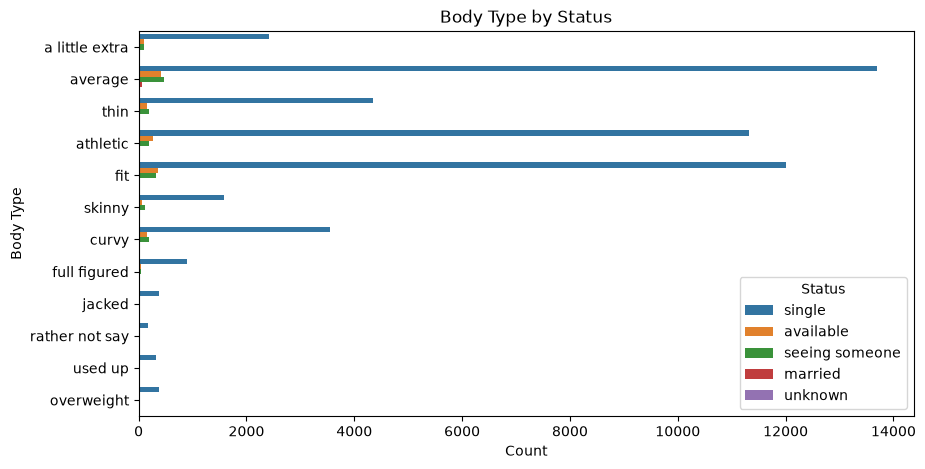

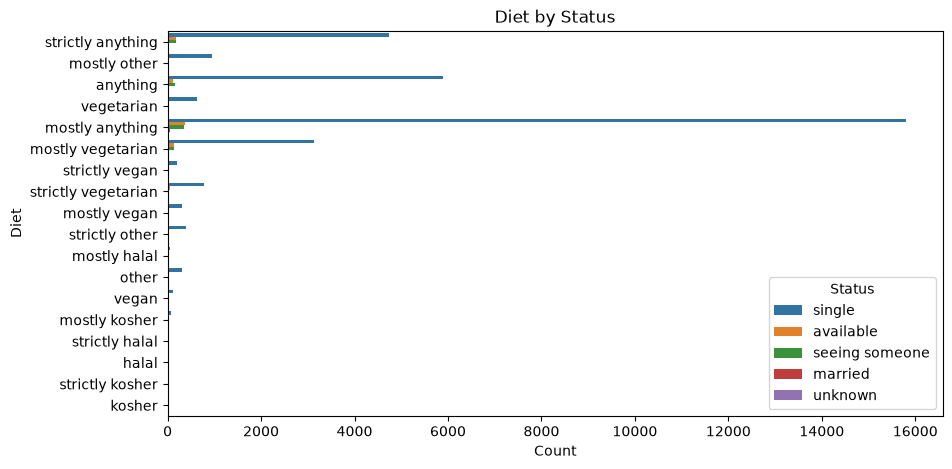

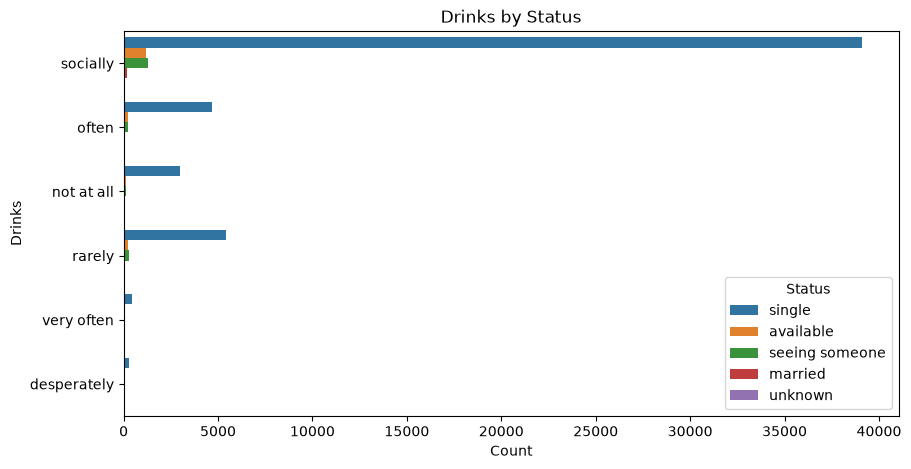

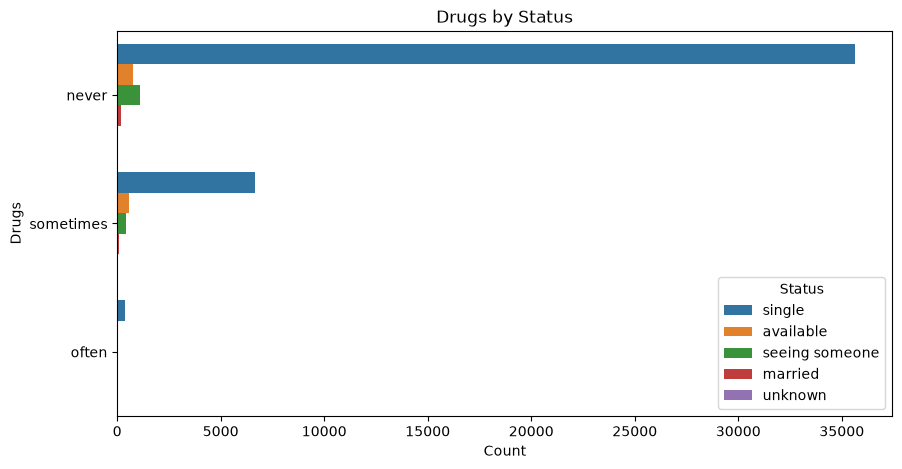

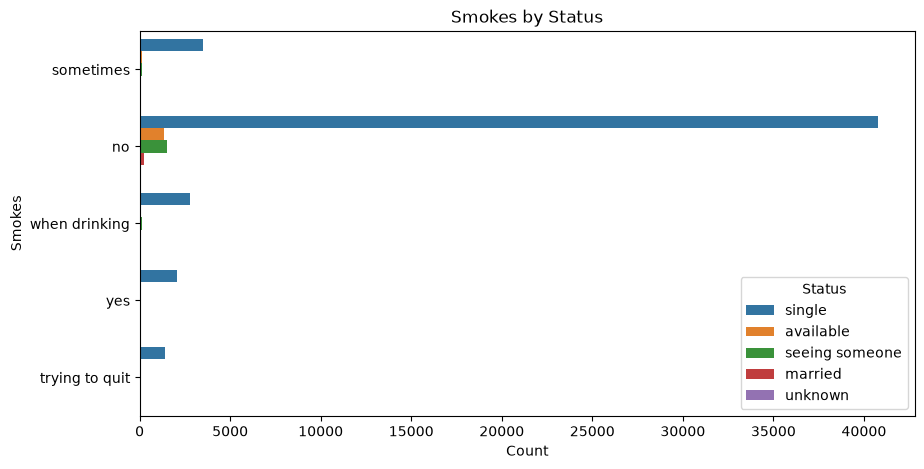

In [30]:
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=health_profiles,
                  y=feature,
                  hue='status')
    plt.xlabel('Count')
    plt.ylabel(feature.replace('_', ' ').title()) # reformat feature values to improve legibility
    plt.legend(title='Status', loc='lower right')
    plt.title(f'{feature.replace("_", " ").title()} by Status')
    plt.show()

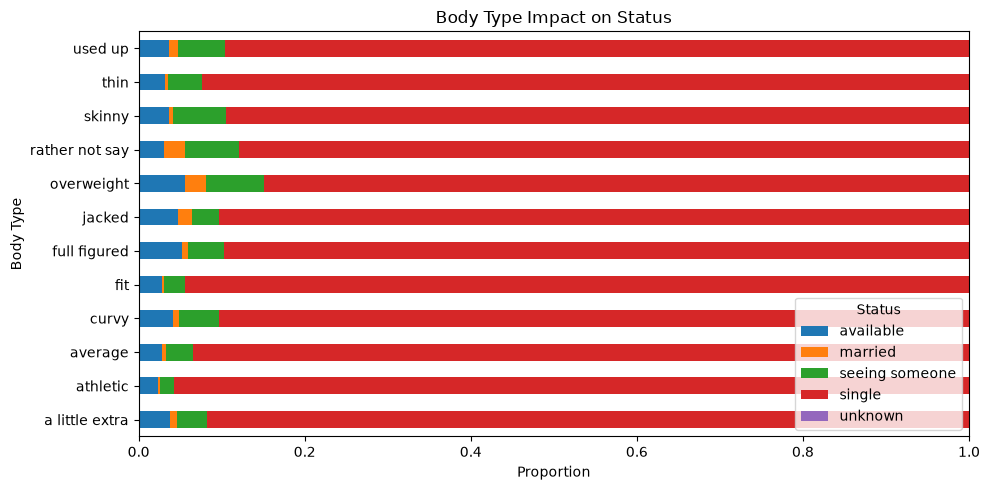

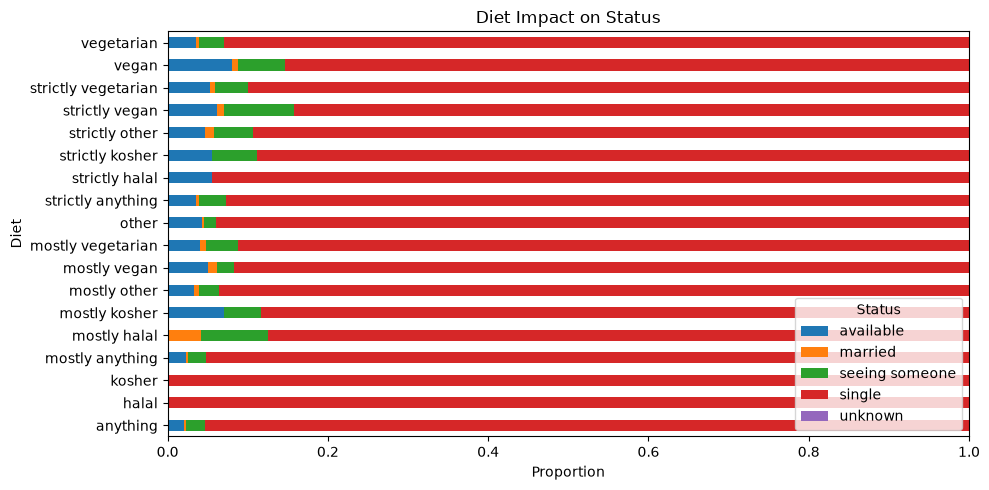

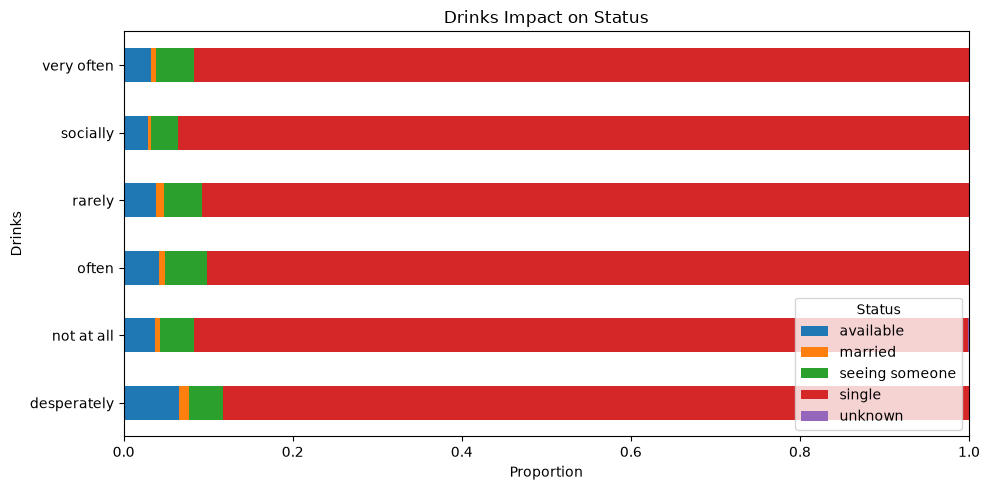

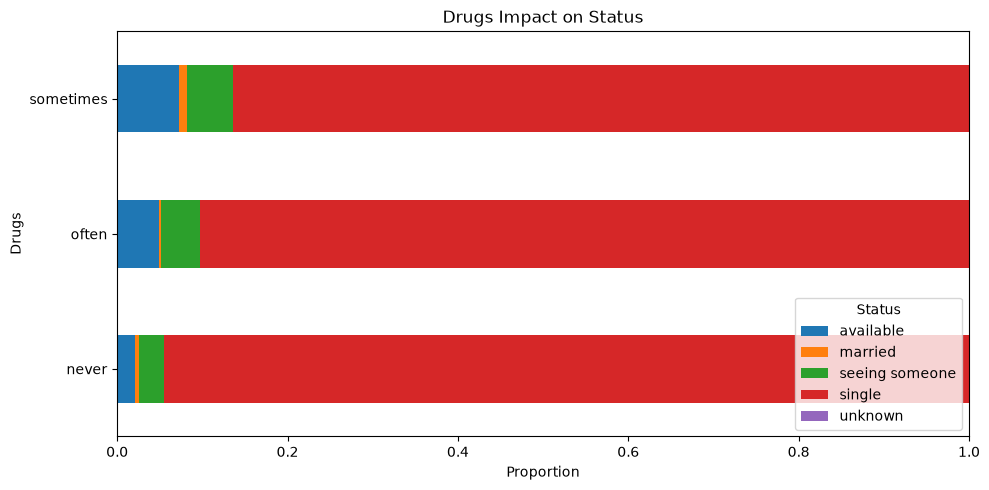

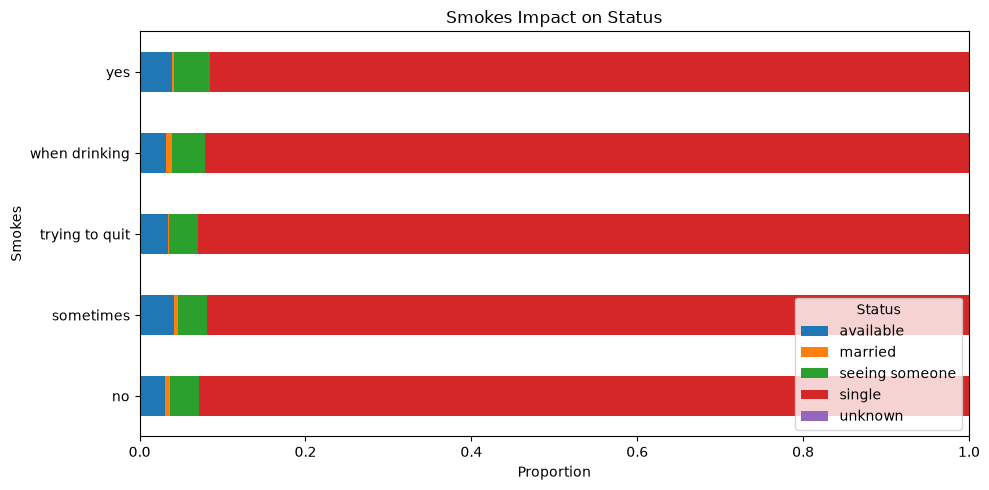

In [31]:
for feature in features:
    proportions = pd.crosstab(health_profiles[feature],
                              health_profiles[outcome],
                              normalize='index')
    proportions.plot(kind='barh',
                     stacked=True,
                     figsize=(10,5))
    plt.xlabel('Proportion')
    plt.ylabel(feature.replace('_', ' ').title()) # reformats column names to improve legibility
    plt.title(f'{feature.replace("_", " ").title()} Impact on Status')
    plt.legend(title='Status', loc='lower right')
    plt.tight_layout()
    plt.show()

### Preprocess Data

In [32]:
# Replace missing data
health_profiles[features] = health_profiles[features].fillna('did not answer')

In [33]:
# Remove all status instances of 'unknown'
health_profiles = health_profiles.loc[profiles['status']!='unknown', health_cols]

In [34]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X, y = health_profiles[features], health_profiles[outcome]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.80,
                                                    random_state=42,
                                                    stratify=y)

In [35]:
# Encode training and testing sets
from sklearn.preprocessing import OneHotEncoder
feature_encoder = OneHotEncoder()
X_train_encoded = feature_encoder.fit_transform(X_train) # learns categories before transforming
X_test_encoded = feature_encoder.transform(X_test)

## Build and Evaluate Models

In [36]:
from sklearn.metrics import (balanced_accuracy_score, # average recall (the ability of a classifier to find all true positives) across all classes
                             classification_report, # contains all accuracy metrics
                             confusion_matrix, # rows = actual classes; columns = predicted classes
                             ConfusionMatrixDisplay)

### The Baseline

In [37]:
from sklearn.dummy import DummyClassifier
baseline = DummyClassifier()
baseline.fit(X_train_encoded, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](4,)","[0.03,0.01,0.03,0.93]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[object](4,)","['available','married','seeing someone','single']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,49
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


Baseline Balanced Accuracy: 25.0%
Baseline Classification Report:
                 precision    recall  f1-score   support

     available       0.00      0.00      0.00       373
       married       0.00      0.00      0.00        62
seeing someone       0.00      0.00      0.00       413
        single       0.93      1.00      0.96     11140

      accuracy                           0.93     11988
     macro avg       0.23      0.25      0.24     11988
  weighted avg       0.86      0.93      0.90     11988



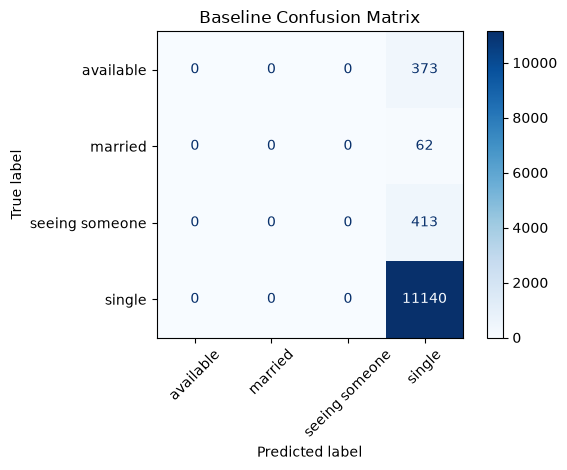

In [38]:
y_pred = baseline.predict(X_test_encoded)
print(f'Baseline Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred)*100}%')
print('Baseline Classification Report:\n', classification_report(y_test, y_pred, zero_division=0))

labels = baseline.classes_
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        labels=labels,
                                        display_labels=labels,
                                        cmap='Blues',
                                        xticks_rotation=45)
plt.title('Baseline Confusion Matrix')
plt.tight_layout()
plt.show()

**Observations:**
* Although the baseline achieved 93% accuracy, its balanced accuracy was only 25%. This means the model does a generally poor job of recognising each class (especially the minority classes). 
* This is proven further by the fact that F1-scores, precision scores, etc for users who weren't single were zero.

**Verdict:** Stratified k-fold cross-validation and hyperparameter tuning can help give minority classes like `married` more importance in forthcoming models.

### Candidate Models
Two classification algorithms will be used and compared alongside the baseline:
* Logistic regression, because the majority of this data is one-hot-encoded. Since there are multiple outcomes, the multiclass variety will be used.
* A random forest, which, unlike a decision tree, is ideal for handling a multitude of features which arise from one-hot encoding. In addition, it is my top priority to obtain as many correct predictions about status based on health.

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, # typically used with very large datasets, like this one 
                      shuffle=True,
                      random_state=42)

#### Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(solver='lbfgs', # handles multiple classes
                        class_weight='balanced', # treats minority classes as equal to the majority class
                        max_iter=1000,
                        random_state=42)

In [41]:
lr_grid = {'C': [0.001, 0.01, 1, 10, 100]}
lr_search = GridSearchCV(estimator=lr,
                         param_grid=lr_grid,
                         scoring='balanced_accuracy',
                         cv=skf,
                         n_jobs=-1)
lr_search.fit(X_train_encoded, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of inf

#### Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight='balanced_subsample', # a practical default for imbalanced random forests  
                            max_depth=10,
                            random_state=42)

In [43]:
rf_grid = {'n_estimators': [100, 300],
           'max_depth': [5, 10, None],
           'min_samples_leaf': [5, 20]}
rf_search = GridSearchCV(estimator=rf,
                         param_grid=rf_grid,
                         scoring='balanced_accuracy',
                         cv=skf,
                         n_jobs=-1)
rf_search.fit(X_train_encoded, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [5, 20], 'n_estimators': [100, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"v

In [47]:
final_model = rf_search.best_estimator_
print(f'Random Forest Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred)*100:.3f}%')
print('Random Forest Report:\n', classification_report(y_test, y_pred, zero_division=0))

Random Forest Balanced Accuracy: 36.329%
Random Forest Report:
                 precision    recall  f1-score   support

     available       0.05      0.33      0.09       373
       married       0.02      0.37      0.03        62
seeing someone       0.05      0.16      0.07       413
        single       0.96      0.59      0.73     11140

      accuracy                           0.57     11988
     macro avg       0.27      0.36      0.23     11988
  weighted avg       0.89      0.57      0.68     11988



### Which Model Is Superior?

In [45]:
compare_models = pd.DataFrame({'model': ['Logistic Regression', 'Random Forest'],
                               'best_cv_balanced_accuracy': [lr_search.best_score_, rf_search.best_score_],
                               'best_parameters': [lr_search.best_params_, rf_search.best_params_]})

compare_models

,model,best_cv_balanced_accuracy,best_parameters
0,Logistic Regression,0.362124,{'C': 1}
1,Random Forest,0.351671,"{'max_depth': 10, 'min_samples_leaf': 20, 'n_e..."


**Observations:**
* The ideal logistic regression model requires default regularisation (i.e. `C`=1). This means that the training data is trusted enough not to result in underfitting and overfitting.
* The ideal random forest has a depth of 10 and 20 training data points per leaf, although the number of estimators is not visible. All things considered, it resists overfitting at the cost of accuracy.

**Verdict:** Because both models have relatively low balanced accuracy scores, neither algorithm can reliably use health data alone to predict relationship status, even when subjected to stratified cross-validation and hyperparameter tuning. However, because logistic regression achieves the higher score, it is the better candidate as the final model.

Logistic Regression Balanced Accuracy: 34.948%
Logistic Regression Report:
                 precision    recall  f1-score   support

     available       0.05      0.29      0.08       373
       married       0.01      0.42      0.02        62
seeing someone       0.05      0.18      0.07       413
        single       0.96      0.50      0.66     11140

      accuracy                           0.49     11988
     macro avg       0.27      0.35      0.21     11988
  weighted avg       0.89      0.49      0.62     11988



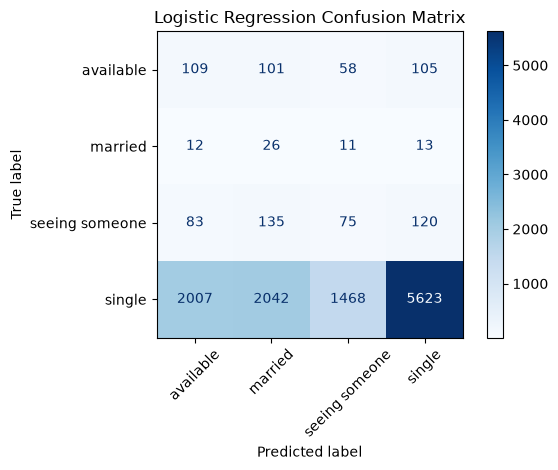

In [46]:
final_model = lr_search.best_estimator_
y_pred = final_model.predict(X_test_encoded)
print(f'Logistic Regression Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred)*100:.3f}%')
print('Logistic Regression Report:\n', classification_report(y_test, y_pred, zero_division=0))
labels = final_model.classes_
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        labels=labels,
                                        display_labels=labels,
                                        cmap='Blues',
                                        xticks_rotation=45)
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

**Observations:**
* Although logistic regression achieved a higher balanced accuracy than the baseline's (35% to the latter's 25%), this improvement came at a substantial cost. Not only did overall accuracy plummet from 93% to 49%, but the chosen model's macro F1-score dropped from 24% to 21%.
* Minority-class identification also had some issues. For one thing, precision for classes such as `married` and `available` was very low (1% and 5%, respectively). In addition, although more true positives were identified (e.g. 109 users in the `available` class), the rest of the predictions were false positives (e.g. 135 users predicted as `married` were actually `seeing someone`).

**Verdict:** Logistic regression's low precision and macro F1-score prevent it from reliably determining a relationship between health and relationship status.

## Conclusion
* Contrary to what I had expected, health alone is a weak predictor of relationship status. I find this development highly unusual because dating apps almost always stress sex appeal -- surely a fit person who eats well would be more likely to see someone or be already married than an unfit person.
* However, this does not necessarily mean the results were useless; in fact, they can perfectly encapsulate the limitations of the original hypothesis and inform better directions in future (see **Next Steps** below for more details).
    * First of all, these findings indicate that other factors in the original dataset could carry more predictive information about relationship status. For example, a user with children could be either divorced (hence the `available` or `seeing someone` options) or married.
    * In addition, algorithm complexity does not automatically guarantee better performance. Careful feature selection and preliminary class imbalance trump stratified cross-validation and grid-search tuning.

## Next Steps
* Expand the feature set to include attributes such as age, education, offspring preferences, location, and sexual orientation. Those profile attributes can influence status more than health alone.
* Use natural language processing techniques -- which were beyond the scope of this career path -- on the essay questions. Their responses have the potential to contain valuable information about users' lifestyles, personalities, interests, and relationship preferences.
* Separate the `offspring` field into two -- one field describes whether a user has children, and another describes whether they want children. Because the majority of the existing text describes preferences rather than containing numbers, natural language processing can be used as well.